In [6]:
import pandas as pd
from sklearn import datasets

In [ ]:
df = pd.read_csv("iris.csv")

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


In [8]:
iris = datasets.load_iris()

In [10]:
print(iris.target_names)
print(iris.feature_names)

['setosa' 'versicolor' 'virginica']
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [12]:
print(iris.data[0:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [13]:
print(iris.target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [15]:
x = df[["sepal_length","sepal_width","petal_length","petal_width"]]
y = df["species"]

In [31]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.3,random_state=42)

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
rfc = RandomForestClassifier(n_estimators=100) #100 descision trees
rfc.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
y_pred = rfc.predict(x_test)

In [35]:
from sklearn import metrics

metrics.confusion_matrix(y_test,y_pred)

array([[19,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 13]])

In [36]:
metrics.accuracy_score(y_test,y_pred)

1.0

In [39]:
print(rfc.predict([[3,5,4,2]]))

['virginica']


C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [40]:
import pandas as pd

In [43]:
feature_imp = pd.Series(rfc.feature_importances_,index=iris.feature_names).sort_values(ascending=False)
print(feature_imp)

petal length (cm)    0.432429
petal width (cm)     0.413733
sepal length (cm)    0.110363
sepal width (cm)     0.043476
dtype: float64


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

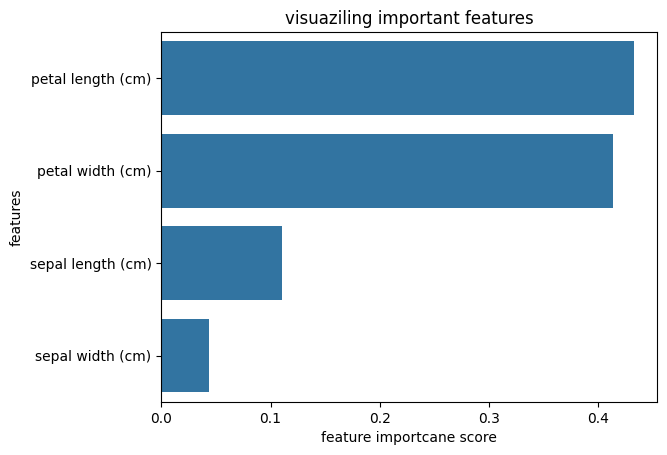

In [50]:
sns.barplot(x = feature_imp,y = feature_imp.index)

plt.xlabel("feature importcane score")
plt.ylabel("features")
plt.title("visuaziling important features")

plt.show()

AS WE COME TO KNOW THAT PETAL LENGTH AND PETAL WIDTH ARE THE TWO FEATURES THAT ARE THE MOST DOMINANT IN DECIDEING THE RESULT THEN WE WILL NOW TRAIN OUR MODEL ON JUST THESE TWO

In [52]:
x = df[["petal_length","petal_width"]]
y = df["species"]

In [54]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.3,random_state=42)

In [56]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()

In [57]:
rfc.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
y_pred = rfc.predict(x_test)

In [59]:
metrics.confusion_matrix(y_test,y_pred)

array([[19,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 13]])

In [60]:
print("accuracy",metrics.accuracy_score(y_test,y_pred))

accuracy 1.0
